In [ ]:
!pip install gdsfactory

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.4/836.4 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

### Import dependencies

In [ ]:
from functools import partial
from pydantic import validate_call
import gdsfactory as gf
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/Shareddrives/2DM/01 User Accounts/Sarkar/FDTD SPP

/content/drive/Shareddrives/2DM/01 User Accounts/Sarkar/FDTD SPP


### Define functions

In [ ]:
def add_HMS(c, x0, y0, N_X, P_X, W_X, W_Y):
    # Create and add a polygon from separate lists of x points and y points
    # (Can also be added like [(x1,y1), (x2,y2), (x3,y3), ... ]
  for x in range(0, N_X):
      p0 = (x0 + x * P_X, y0)
      p1 = (x0 + x * P_X + W_X, y0)
      p2 = (x0 + x * P_X + W_X, y0 + W_Y)
      p3 = (x0 + x * P_X, y0 + W_Y)
      c.add_polygon(
          [p0, p1, p2, p3], layer=(1, 0)
    )  # GDS layers are tuples of ints (but if we use only one number it assumes the other number is 0)
  return c

def add_taper_coupler(c, x0, y0, N_Y, P_Y, W_X, W_Y):
    # Create and add a polygon from separate lists of x points and y points
    # (Can also be added like [(x1,y1), (x2,y2), (x3,y3), ... ]
  for y in range(0, N_Y):
      p0 = (x0, y0 + y * P_Y)
      p1 = (x0, y0 + y * P_Y + W_Y)
      p2 = (x0 + W_X, y0 + y * P_Y + W_Y)
      p3 = (x0 + W_X, y0 + y * P_Y)
      c.add_polygon(
          [p0, p1, p2, p3], layer=(1, 0)
    )  # GDS layers are tuples of ints (but if we use only one number it assumes the other number is 0)
  return c

def add_cylindrical_coupler(c, x0, y0, N_X, N_Y, P_X, P_Y, R):
  for x in range(0, N_X):
    for y in range(0, N_Y):
      E = gf.components.circle(radius=R, layer=(3, 0))
      circle = c.add_ref(E)
      circle.movex(x0 + x * P_X)
      circle.movey(y0 + y * P_Y)
  return c

## Ultra-small period

In [ ]:
u = gf.Component("Umklapp")

length = 20
Nwg = 200
period_HMS = 0.05
w_HMS = 0.025

x0, y0 = -30, 35
c = add_HMS(u, x0, y0, Nwg, period_HMS, w_HMS, length)
t = gf.components.text("0-w25", size=2, layer=(4, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

ComponentReference (parent Component "text_322fd24f", ports [], origin (-40.0, 50.0), rotation 0.0, x_reflection False)

## Cylindrical grating

In [ ]:
x_dev_spacing = 25
y_dev_spacing = 35

######## HMS params #########

length = 15
Nwg = 30
period_HMS = 0.15

######## Clylindrical grating params #########

R = 0.075
period_coupler = 0.2
HMS_coupler_spacing = 0.05

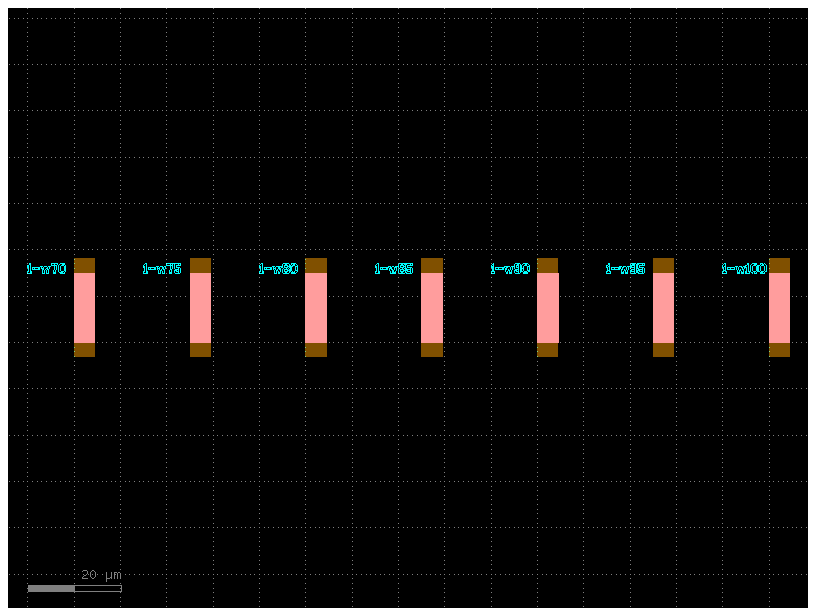

In [ ]:
c = gf.Component("HMS+Cylindrical grating")

######## w=70 #########

x0, y0 = -4*x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.070, length)
t = gf.components.text("1-w70", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=75 #########

x0, y0 = -3*x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.075, length)
t = gf.components.text("1-w75", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=80 #########

x0, y0 = -2*x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.080, length)
t = gf.components.text("1-w80", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=85 #########

x0, y0 = -x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.085, length)
t = gf.components.text("1-w85", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=90 #########

x0, y0 = 0, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.09, length)
t = gf.components.text("1-w90", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=95 #########

x0, y0 = x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.095, length)
t = gf.components.text("1-w95", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

######## w=100 #########

x0, y0 = 2*x_dev_spacing, 0
c = add_HMS(c, x0, y0, Nwg, period_HMS, 0.1, length)
t = gf.components.text("1-w100", size=2, layer=(2, 0))
text1 = c.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)
c = add_cylindrical_coupler(c, x0, y0 + length + R + HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
c = add_cylindrical_coupler(c, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)

c.show()  # show it in klayout
c.plot()  # plot it in jupyter notebook

## Defect

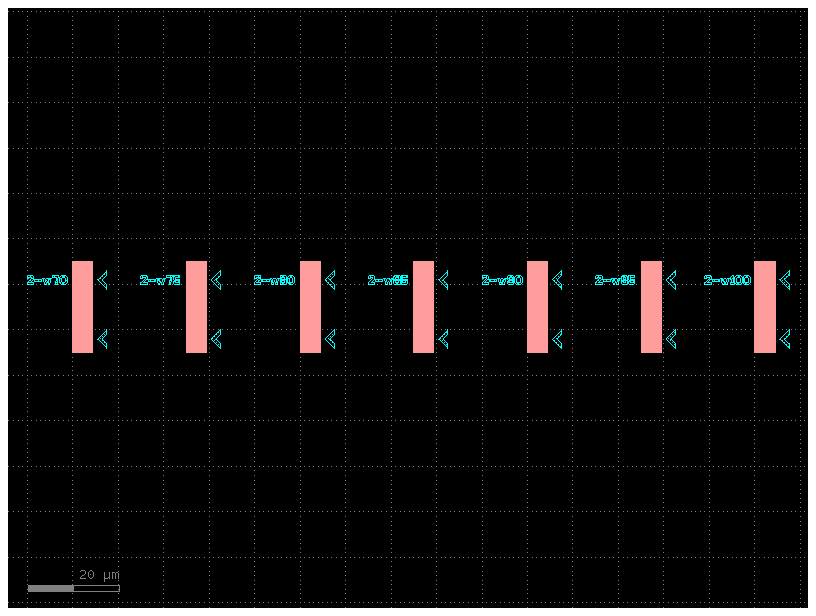

In [ ]:
defect = gf.Component("Defect")

######## HMS params #########

length = 20
Nwg = 30
period_HMS = 0.15

######## Defect grating params #########

position_from_top = 4
distance = 13

######### Arrow ##############

#arrow = gf.Component("Arrow")
w = 1

p0 = [0, 0]
p1 = [2 , 2]
p2 = [2 , 2 - w]
p3 = [w,0]
p4 = [2, -2 + w]
p5 = [2, -2]

######## w=70 #########

w = 0.07

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = -4*x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w70", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=75 #########

w = 0.075

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = -3*x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w75", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=80 #########

w = 0.08

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = -2*x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w80", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=85 #########

w = 0.085

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = -x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w85", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=90 #########

w = 0.09

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = 0, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w90", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=95 #########

w = 0.095

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w95", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 10).movey(y0 + 15)

######## w=100 #########

w = 0.1

c01 = gf.Component("Layer1")
c02 = gf.Component("Layer2")

x0, y0 = 2*x_dev_spacing, -y_dev_spacing
c02 = add_HMS(c01, x0, y0, Nwg, period_HMS, w, length)
box = gf.components.rectangle(size=[w, w], layer=(1, 0))
defect1 = c01.add_ref(box).movex(x0 + 15*period_HMS).movey(y0 + length - position_from_top)
box = gf.components.rectangle(size=[Nwg*period_HMS, w], layer=(1, 0))
defect2 = c01.add_ref(box).movex(x0 + 0*period_HMS).movey(y0 + length - position_from_top - distance)
c02 = gf.geometry.boolean(A=c01, B=[defect1,defect2], operation="A-B", precision=1e-6, layer=(1, 0))
defect.add_ref(c02)

arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top)
arrow = defect.add_polygon([p0,p1,p2,p3,p4,p5], layer=[2,0]).movex(x0 + Nwg*period_HMS + 1).movey(y0 + length - position_from_top - distance)

t = gf.components.text("2-w100", size=2, layer=(2, 0))
defect.add_ref(t).movex(x0 - 11).movey(y0 + 15)

defect.show()  # show it in klayout
defect.plot()  # plot it in jupyter notebook

## Tapered grating

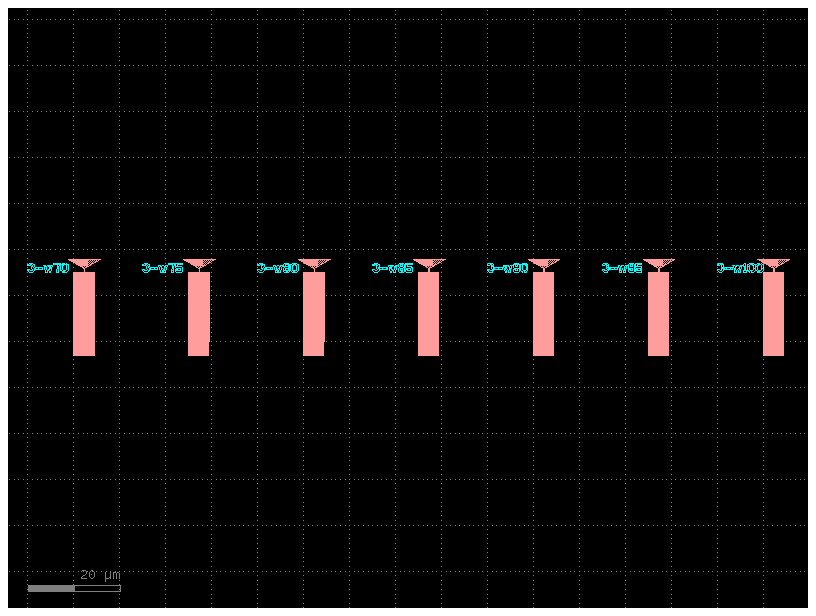

In [ ]:
tg = gf.Component("HMS+Taper grating")

length = 15
length_ridge = 12

p0 = [0,0]
p1 = [np.sqrt(3)*2,2]
p2 = [-np.sqrt(3)*2,2]

Wx = 1.5
Wy = 0.1
Py = 0.2
Ny = 6

######## w=70 #########

w= 0.07

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = -4*x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w70", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)


######## w=75 #########

w= 0.075

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = -3*x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w75", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

######## w=80 #########

w= 0.08

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = -2*x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w80", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

######## w=85 #########

w= 0.085

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = -x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w85", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

######## w=90 #########

w= 0.090

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = 0, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w90", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

######## w=95 #########

w= 0.095

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2,  y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w95", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

######## w=100 #########

w= 0.1

tg00 = gf.Component("temp")
tg03 = gf.Component("temp")

x0, y0 = 2*x_dev_spacing, -2*y_dev_spacing
tg01 = add_HMS(tg00, x0, y0, Nwg, period_HMS, w, length)
tg01 = add_cylindrical_coupler(tg00, x0, y0 - period_coupler*15 - R - HMS_coupler_spacing, int(period_HMS*Nwg/period_coupler)+1, 16, period_coupler, period_coupler, R)
add_HMS(tg00, x0 + 15*period_HMS, y0, 1, period_HMS, w, length+1)
tg00.add_polygon([p0, p1, p2], layer=(1, 0)).movex(x0 + 15*period_HMS + w/2).movey(y0 + length + 0.8)
tg02 = gf.geometry.boolean(A=tg00, B=tg01, operation="A+B", precision=1e-6, layer=(1, 0))
tg04 = add_taper_coupler(tg03, x0 + 10*period_HMS + w/2, y0+length+1.5, Ny, Py, Wx, Wy)
tg04 = gf.geometry.boolean(A=tg02, B=tg03, operation="A-B", precision=1e-6, layer=(1, 0))
tg.add_ref(tg04)

t = gf.components.text("3-w100", size=2, layer=(2, 0))
text1 = tg.add_ref(t)
text1.movex(x0 - 10)
text1.movey(y0 + 15)

tg.show()  # show it in klayout
tg.plot()

## Add everything

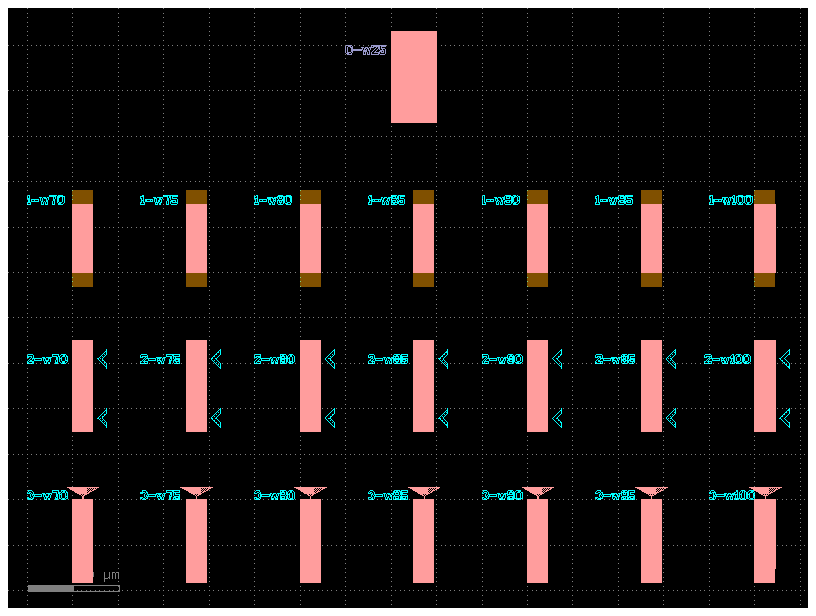

In [ ]:
chip1 = gf.Component("chip1")

# Ultra-small period
chip1.add_ref(u).movey(-2)

# Cylindrical pillars
chip1.add_ref(c)

# Defects
chip1.add_ref(defect)

# Defects
chip1.add_ref(tg).movey(5)

#chip1.write_gds("demo.gds")
chip1.show()  # show it in klayout
chip1.plot()  # plot it in jupyter notebook

## Make multiple copies

2024-05-07 22:20:46.934 | INFO     | gdsfactory.component:_write_library:2003 - Wrote to 'Plasmonics_fab_design_07052024.gds'


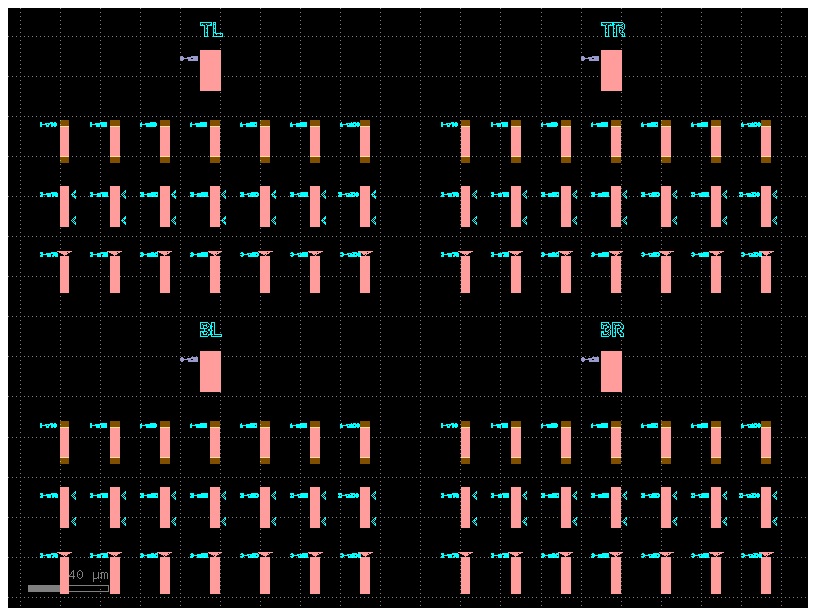

In [ ]:
chip = gf.Component("chip")

xdist = 200
ydist = 150

chip.add_ref(chip1)
t = gf.components.text("TL", size=7, layer=(2, 0))
text1 = chip.add_ref(t).movex(-30).movey(60)

chip.add_ref(chip1).movex(xdist)
t = gf.components.text("TR", size=7, layer=(2, 0))
text1 = chip.add_ref(t).movex(-30 + xdist).movey(60)

chip.add_ref(chip1).movey(-ydist)
t = gf.components.text("BL", size=7, layer=(2, 0))
text1 = chip.add_ref(t).movex(-30).movey(60 - ydist)

chip.add_ref(chip1).movex(xdist).movey(-ydist)
t = gf.components.text("BR", size=7, layer=(2, 0))
text1 = chip.add_ref(t).movex(-30 + xdist).movey(60 - ydist)

chip.write_gds("Plasmonics_fab_design_07052024.gds")

chip.show()  # show it in klayout
chip.plot()  # plot it in jupyter notebook